In [ ]:
!pip install -q "deepdoctection" "transformers>=5.2.0" "timm" "python-doctr" "pdfplumber" "networkx" "lxml"

import os
os.environ["DD_USE_TORCH"]  = "True"
os.environ["DPI"]           = "200"
os.environ["LOG_LEVEL"]     = "INFO"
os.environ["ENABLE_DYNAMIC_OBJECT_TYPES"] = "False"

import json, re, textwrap
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, display

import deepdoctection as dd
print("deepdoctection:", dd.__version__)

import transformers.integrations.peft as _hf_peft
if _hf_peft.is_peft_available():
    _hf_peft.is_peft_available = lambda: False
    print("patched: PEFT adapter lookup disabled for from_pretrained")

!mkdir -p /content/docs /content/imgs
!wget -q -O /content/docs/paper.pdf \
  https://raw.githubusercontent.com/deepdoctection/notebooks/main/sample/2312.13560.pdf
!wget -q -O /content/imgs/finance.png \
  https://raw.githubusercontent.com/deepdoctection/notebooks/main/sample/finance/1bcac3899c9cb1c0b0f650b1431d3d52_7.png

PDF = Path("/content/docs/paper.pdf")
PNG = Path("/content/imgs/finance.png")
OUT = Path("/content/out"); OUT.mkdir(exist_ok=True)

def show(img, w=16):
    if img is None: return
    plt.figure(figsize=(w, w * 1.3)); plt.axis("off"); plt.imshow(img); plt.show()

def analyze_any(pipe, path, **kw):
    """
    Dispatch correctly for a directory, a PDF, or a single image file.

    DoctectionPipe can stream a directory or a PDF from disk, but a *single*
    image has no reader — path= only supplies the file name / provenance, and
    the pixels must be handed in via bytes=. Without this you get:
      ValueError: When passing a path to a single image, bytes of the image
                  must be passed
    """
    path = Path(path)
    if path.is_dir():
        kw.setdefault("file_type", [".jpg", ".png", ".jpeg", ".tif"])
        return pipe.analyze(path=path, **kw)
    if path.suffix.lower() == ".pdf":
        return pipe.analyze(path=path, **kw)
    if path.suffix.lower() in (".png", ".jpg", ".jpeg", ".tif"):
        return pipe.analyze(path=path, bytes=path.read_bytes(), **kw)
    raise ValueError(f"unsupported input: {path}")

In [ ]:
dd.print_model_infos(add_description=False, add_config=False, add_categories=False)

profile = dd.ModelCatalog.get_profile("Aryn/deformable-detr-DocLayNet/model.safetensors")
print("\nlayout model categories:", profile.categories)
print("is registered:", dd.ModelCatalog.is_registered("Aryn/deformable-detr-DocLayNet/model.safetensors"))

config_overwrite = [
    "USE_ROTATOR=False",
    "USE_LAYOUT=True",
    "USE_LAYOUT_NMS=True",
    "USE_TABLE_SEGMENTATION=True",
    "USE_TABLE_REFINEMENT=False",
    "USE_PDF_MINER=False",
    "USE_OCR=True",
    "USE_LAYOUT_LINK=True",
    "LAYOUT.WEIGHTS=Aryn/deformable-detr-DocLayNet/model.safetensors",
    "ITEM.WEIGHTS=deepdoctection/tatr_tab_struct_v2/model.safetensors",
    "ITEM.FILTER=['table']",
    "OCR.USE_DOCTR=True",
    "OCR.USE_TESSERACT=False",
    "OCR.USE_TEXTRACT=False",
    "OCR.WEIGHTS.DOCTR_WORD=doctr/db_resnet50/db_resnet50-ac60cadc.pt",
    "OCR.WEIGHTS.DOCTR_RECOGNITION=doctr/crnn_vgg16_bn/crnn_vgg16_bn-0417f351.pt",
    "SEGMENTATION.THRESHOLD_ROWS=0.4",
    "SEGMENTATION.THRESHOLD_COLS=0.4",
    "SEGMENTATION.FULL_TABLE_TILING=True",
    "WORD_MATCHING.RULE=ioa",
    "WORD_MATCHING.THRESHOLD=0.3",
    "WORD_MATCHING.MAX_PARENT_ONLY=True",
    "TEXT_ORDERING.INCLUDE_RESIDUAL_TEXT_CONTAINER=True",
    "TEXT_ORDERING.PARAGRAPH_BREAK=0.035",
    "TEXT_ORDERING.BROKEN_LINE_TOLERANCE=0.003",
    "LAYOUT_LINK.PARENTAL_CATEGORIES=['figure','table']",
    "LAYOUT_LINK.CHILD_CATEGORIES=['caption']",
]

analyzer = dd.get_dd_analyzer(config_overwrite=config_overwrite)

print("\n--- pipeline ---")
for sid, name in analyzer.get_pipeline_info().items():
    print(f"{sid}  {name}")
print("\n--- what this pipeline produces ---")
print(analyzer.get_meta_annotation())

In [ ]:
df = analyze_any(analyzer, PDF, session_id="tutorial01", max_datapoints=3)
df.reset_state()
pages = list(df)
print(f"\nparsed {len(pages)} pages")

page = pages[0]
show(page.viz(show_figures=True, show_residual_layouts=True, show_table_structure=True))

print("== narrative text ==")
print(textwrap.fill(page.text[:900], 110))

print("\n== layout blocks in reading order ==")
for doc_id, img_id, pno, ann_id, order, cat, txt in page.chunks[:12]:
    print(f"[{order:>3}] {str(cat):<15} {txt[:70]!r}")

print("\n== category histogram ==")
print(Counter(a.category_name for a in page.get_annotation()))

for fig in page.figures:
    linked = fig.get_relationship("layout_link")
    print("figure", fig.annotation_id[:8], "-> caption ids:", [i[:8] for i in linked])

if page.words:
    w = page.words[0]
    print("\nword:", w.characters, "| service:", w.service_id,
          "| model:", w.model_id, "| bbox:", [round(x) for x in w.bbox])

tbl_pages = [p for p in pages if p.tables]
if tbl_pages:
    t = tbl_pages[0].tables[0]
    print(f"table {t.number_of_rows}x{t.number_of_columns}, "
          f"max_row_span={t.max_row_span}, max_col_span={t.max_col_span}")
    display(HTML(t.html))
    for row in t.csv[:5]:
        print([c[:22] for c in row])
    for c in t.cells[:5]:
        print(f"  r{c.row_number} c{c.column_number} "
              f"(span {c.row_span}x{c.column_span}) {c.text[:40]!r}")
else:
    print("no table on these pages — the finance.png sample below has one")

In [ ]:
@dd.object_types_registry.register("CustomKey")
class CustomKey(dd.ObjectTypes):
    """Custom summary keys — must be registered to be serialisable."""
    MONEY_MENTIONS = "money_mentions"
    DATE_MENTIONS  = "date_mentions"
    DOC_FLAVOUR    = "doc_flavour"

@dd.object_types_registry.register("FlavourLabel")
class FlavourLabel(dd.ObjectTypes):
    TABULAR   = "tabular"
    NARRATIVE = "narrative"
    MIXED     = "mixed"

MONEY = re.compile(r"(?:[$€£]\s?\d[\d,.]*|\d[\d,.]*\s?(?:USD|EUR|GBP|million|bn))")
DATE  = re.compile(r"\b(?:\d{1,2}[/-]\d{1,2}[/-]\d{2,4}|\d{4}-\d{2}-\d{2}|"
                   r"(?:Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)\w*\s+\d{1,2},?\s+\d{4})\b")

class EntityAndFlavourService(dd.PipelineComponent):
    def __init__(self, name="entity_flavour", tabular_ratio=0.25):
        self.tabular_ratio = tabular_ratio
        super().__init__(name)

    def serve(self, dp: dd.Image) -> None:
        page = dd.Page.from_image(dp, text_container=dd.LayoutLabel.WORD)
        text = page.text_no_line_break

        money = sorted(set(MONEY.findall(text)))
        dates = sorted(set(DATE.findall(text)))

        tables = page.tables
        table_area = sum((b[2] - b[0]) * (b[3] - b[1]) for b in (t.bbox for t in tables))
        ratio = table_area / float(page.width * page.height or 1)
        flavour = (FlavourLabel.TABULAR if ratio > self.tabular_ratio
                   else FlavourLabel.NARRATIVE if not tables
                   else FlavourLabel.MIXED)

        self.dp_manager.set_summary_annotation(
            summary_key=CustomKey.MONEY_MENTIONS, summary_name=CustomKey.MONEY_MENTIONS,
            summary_value=money)
        self.dp_manager.set_summary_annotation(
            summary_key=CustomKey.DATE_MENTIONS, summary_name=CustomKey.DATE_MENTIONS,
            summary_value=dates)
        self.dp_manager.set_summary_annotation(
            summary_key=CustomKey.DOC_FLAVOUR, summary_name=flavour,
            summary_score=round(ratio, 4))

    def clone(self):
        return self.__class__(self.name, self.tabular_ratio)

    def get_meta_annotation(self) -> dd.MetaAnnotation:
        return dd.MetaAnnotation(
            image_annotations=(),
            sub_categories={},
            relationships={},
            summaries=(CustomKey.MONEY_MENTIONS, CustomKey.DATE_MENTIONS, CustomKey.DOC_FLAVOUR),
        )

for k in (CustomKey.MONEY_MENTIONS, CustomKey.DATE_MENTIONS, CustomKey.DOC_FLAVOUR):
    dd.Page.add_attribute_name(k)

In [ ]:
from deepdoctection.analyzer import cfg, ServiceFactory

cfg.freeze(False)
cfg.USE_TABLE_SEGMENTATION = True
cfg.freeze(True)

components = []
layout_detector = ServiceFactory.build_layout_detector(cfg, mode="LAYOUT")
components.append(ServiceFactory.build_layout_service(cfg, detector=layout_detector, mode="LAYOUT"))
components.append(ServiceFactory.build_layout_nms_service(cfg))

item_detector = ServiceFactory.build_layout_detector(cfg, mode="ITEM")
components.append(ServiceFactory.build_sub_image_service(cfg, detector=item_detector, mode="ITEM"))
components.append(ServiceFactory.build_table_segmentation_service(cfg, detector=item_detector))

word_detector = ServiceFactory.build_doctr_word_detector(cfg)
components.append(ServiceFactory.build_doctr_word_detector_service(word_detector))
components.append(ServiceFactory.build_text_extraction_service(cfg, ServiceFactory.build_ocr_detector(cfg)))
components.append(ServiceFactory.build_word_matching_service(cfg))
components.append(ServiceFactory.build_text_order_service(cfg))
components.append(EntityAndFlavourService())

custom_pipe = dd.DoctectionPipe(pipeline_component_list=components)
print("\ncustom pipeline:", list(custom_pipe.get_pipeline_info().values()))

df2 = analyze_any(custom_pipe, PNG)
df2.reset_state()
fin_page = next(iter(df2))

print("flavour  :", fin_page.doc_flavour)
print("money    :", fin_page.money_mentions[:10])
print("dates    :", fin_page.date_mentions[:10])
show(fin_page.viz(show_table_structure=True), w=13)

def skip_if_no_table(dp: dd.Image) -> bool:
    return "table" not in {a.category_name for a in dp.get_annotation()}
components[-1].set_inbound_filter(skip_if_no_table)

det_sid = next(sid for sid, n in analyzer.get_pipeline_info().items()
               if n.startswith("image_doctr"))
det_comp = analyzer.get_pipeline_component(service_id=det_sid)
df_undo = det_comp.undo(dd.DataFromList([p.base_image for p in pages]))
df_undo.reset_state()
undone = list(df_undo)
print("annotations before/after undo:",
      len(pages[0].get_annotation()),
      len(dd.Page.from_image(undone[0]).get_annotation()))

deepdoctection: 1.2.14


[0815 19:32.58 @dd.py:119]  INF  Config: 
 {'CELL': {'FILTER': None,
          'PAD': {'BOTTOM': 60, 'LEFT': 60, 'RIGHT': 60, 'TOP': 60},
          'PADDING': False,
          'WEIGHTS': 'cell/d2_model_1849999_cell_inf_only.pt',
          'WEIGHTS_TS': 'cell/d2_model_1849999_cell_inf_only.ts'},
 'DEVICE': device(type='cpu'),
 'ENFORCE_WEIGHTS': {'CELL': True, 'ITEM': True, 'LAYOUT': True},
 'ITEM': {'FILTER': ['table'],
          'PAD': {'BOTTOM': 60, 'LEFT': 60, 'RIGHT': 60, 'TOP': 60},
          'PADDING': False,
          'WEIGHTS': 'deepdoctection/tatr_tab_struct_v2/model.safetensors',
          'WEIGHTS_TS': 'item/d2_model_1639999_item_inf_only.ts'},
 'LANGUAGE': None,
 'LAYOUT': {'FILTER': None,
            'PAD': {'BOTTOM': 0, 'LEFT': 0, 'RIGHT': 0, 'TOP': 0},
            'PADDING': False,
            'WEIGHTS': 'Aryn/deformable-detr-DocLayNet/model.safetensors',
            'WEIGHTS_TS': 'layout/d2_model_0829999_layout_inf_only.ts'},
 'LAYOUT_LINK': {'CHILD_CATEGORIES': ['capti

╒═════════════════════════════════════════════════════════════════════╕
│ name                                                                │
╞═════════════════════════════════════════════════════════════════════╡
│ layout/d2_model_0829999_layout_inf_only.pt                          │
├─────────────────────────────────────────────────────────────────────┤
│ layout/d2_model_0829999_layout_inf_only.ts                          │
├─────────────────────────────────────────────────────────────────────┤
│ cell/d2_model_1849999_cell_inf_only.pt                              │
├─────────────────────────────────────────────────────────────────────┤
│ cell/d2_model_1849999_cell_inf_only.ts                              │
├─────────────────────────────────────────────────────────────────────┤
│ item/d2_model_1639999_item_inf_only.pt                              │
├─────────────────────────────────────────────────────────────────────┤
│ item/d2_model_1639999_item_inf_only.ts                        

Loading weights:   0%|          | 0/598 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/367 [00:00<?, ?it/s]

[0815 19:32.59 @fs.py:101]  INF  File db_resnet50-ac60cadc.pt exists! Skip download.
[0815 19:33.00 @fs.py:101]  INF  File crnn_vgg16_bn-0417f351.pt exists! Skip download.
[0815 19:33.02 @data.py:87]  INF  Using downloaded & verified file: /root/.cache/doctr/models/vgg16_bn_r-d108c19c.pt
[0815 19:33.03 @doctectionpipe.py:118]  INF  Processing paper_1.pdf



--- pipeline ---
5497d92c  image_Transformers_Tatr_deformable-detr-DocLayNet_model.safetensors
3b56c997  nms
dc2cd45e  sub_image_Transformers_Tatr_tatr_tab_struct_v2_model.safetensors
03844ddb  table_transformer_segment
7d6a1bc2  image_doctr_db_resnet50db_resnet50_db_resnet50-ac60cadc.pt
50d37ed6  text_extract_doctr_crnn_vgg16_bncrnn_vgg16_bn_crnn_vgg16_bn-0417f351.pt
d6219eba  matching
f10aa678  text_order

--- what this pipeline produces ---
MetaAnnotation(image_annotations=(<DefaultType.DEFAULT_TYPE>, <LayoutLabel.CAPTION>, <LayoutLabel.TEXT>, <LayoutLabel.TITLE>, <LayoutLabel.FOOTNOTE>, <LayoutLabel.FORMULA>, <LayoutLabel.LIST_ITEM>, <LayoutLabel.PAGE_FOOTER>, <LayoutLabel.PAGE_HEADER>, <LayoutLabel.FIGURE>, <LayoutLabel.SECTION_HEADER>, <LayoutLabel.TABLE>, <LayoutLabel.COLUMN>, <LayoutLabel.ROW>, <CellLabel.COLUMN_HEADER>, <CellLabel.PROJECTED_ROW_HEADER>, <CellLabel.SPANNING>, <LayoutLabel.WORD>, <LayoutLabel.LINE>), sub_categories={<LayoutLabel.CELL>: {<CellKey.ROW_NUMBER>: {<

[0815 19:33.26 @context.py:156]  INF  ImageLayoutService total: 23.0557 sec.
[0815 19:33.26 @context.py:156]  INF  AnnotationNmsService total: 0.0044 sec.
[0815 19:33.26 @context.py:156]  INF  SubImageLayoutService total: 0.0001 sec.
[0815 19:33.26 @context.py:156]  INF  PubtablesSegmentationService total: 0.0001 sec.
[0815 19:33.34 @context.py:156]  INF  ImageLayoutService total: 7.9652 sec.
[0815 19:34.15 @context.py:156]  INF  TextExtractionService total: 40.99 sec.
[0815 19:34.15 @context.py:156]  INF  MatchingService total: 0.0342 sec.
[0815 19:34.15 @context.py:156]  INF  TextOrderService total: 0.0883 sec.
[0815 19:34.15 @context.py:156]  INF  MatchingService total: 0.0022 sec.
[0815 19:34.15 @doctectionpipe.py:118]  INF  Processing paper_2.pdf
[0815 19:34.33 @context.py:156]  INF  ImageLayoutService total: 18.6105 sec.
[0815 19:34.33 @context.py:156]  INF  AnnotationNmsService total: 0.0053 sec.
[0815 19:34.33 @context.py:156]  INF  SubImageLayoutService total: 0.0001 sec.
[081


parsed 3 pages


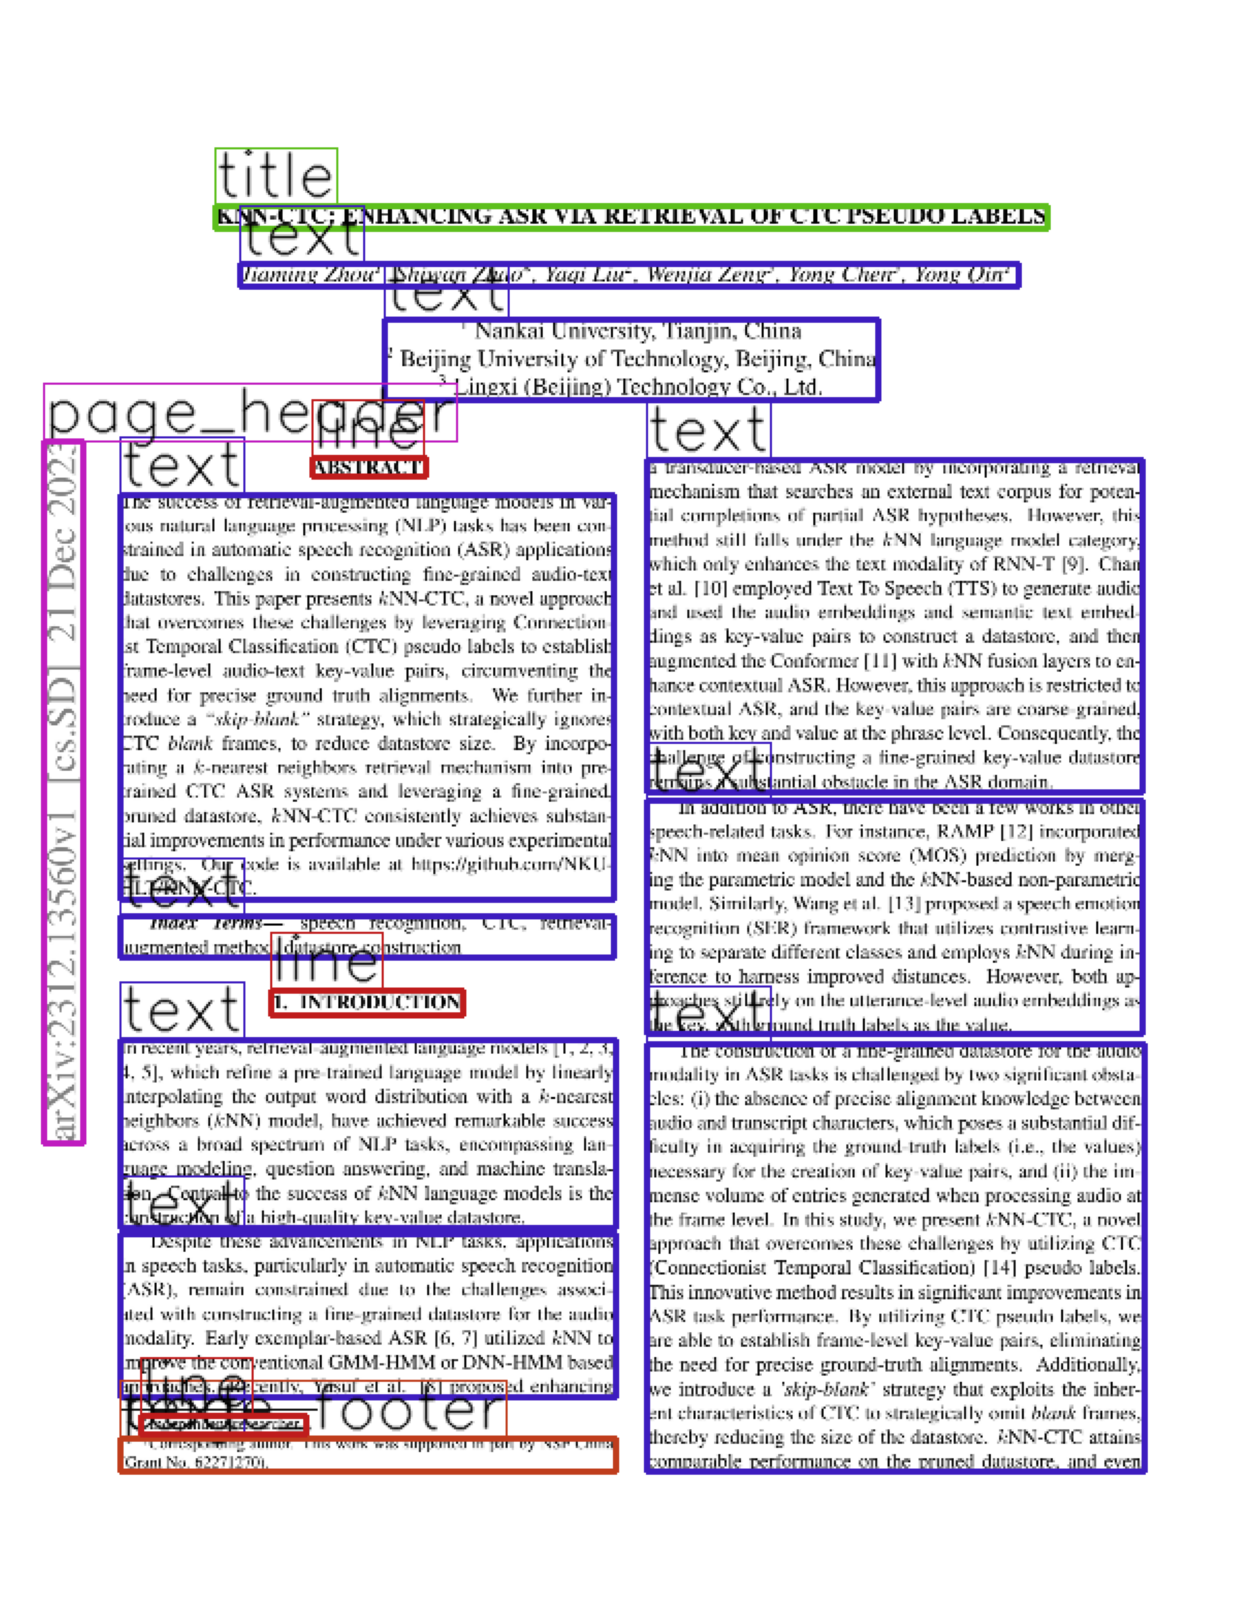

== narrative text ==
KNN-CTC: ENHANCING ASR VIA RETRIEVAL OF CTC PSEUDOLABELS Jiaming Zhou', Shiwan Zhao*, Yaqi Liu, Wenjia Zeng,
Yong Chen', Yong Qin't Nankai University, Tianjin, China 21 Beijing University of Technology, Beijing, China
31 Lingxi (Beijing) Technology Co.,Ltd. ABSTRACT The success of retrieval-augmented language models in var-
ious natural language processing (NLP) tasks has been con- strained in automatic speech recognition (ASR)
applications due to challenges in constructing fine-grained audio-text datastores. This paper presents KNN-
CTC, a novel approach that overcomes these challenges by leveraging Connection- ist Temporal Classification
(CTC) pseudo labels to establish frame-level audio-text key-value pairs, circumventing the need for precise
ground truth alignments. We further in- troduce a "skip-blank" strategy, which strategically ignores CTC blank
frames, to reduce datastore size.

== layout blocks in reading order ==
[  1] LayoutLabel.TITLE 'KNN-CTC: ENHANC

['Table 1. WER/CER (%) o', '', '', '', '']
['Dataset ', 'A-1 ', 'A-2 ', 'Libri-Adapt ', 'Avg. ']
['CTC ', '5.18 ', '6.18 ', '12.81 ', '8.06 ']
['KNN-CTC (full) ', '4.81 ', '5.53 ', '12.42 ', '7.59 ']
['Datastore size (G) ', '7.12 ', '47.12 ', '4.82 ', '19.69 ']
  r1 c1 (span 1x5) 'Table 1. WER/CER (%) of in-domain ASR'
  r2 c1 (span 1x1) 'Dataset'
  r2 c2 (span 1x1) 'A-1'
  r2 c3 (span 1x1) 'A-2'
  r2 c4 (span 1x1) 'Libri-Adapt'


Loading weights:   0%|          | 0/598 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/367 [00:00<?, ?it/s]

[0815 19:36.31 @fs.py:101]  INF  File db_resnet50-ac60cadc.pt exists! Skip download.
[0815 19:36.32 @fs.py:101]  INF  File crnn_vgg16_bn-0417f351.pt exists! Skip download.
[0815 19:36.35 @data.py:87]  INF  Using downloaded & verified file: /root/.cache/doctr/models/vgg16_bn_r-d108c19c.pt
[0815 19:36.35 @doctectionpipe.py:118]  INF  Processing finance.png



custom pipeline: ['image_Transformers_Tatr_deformable-detr-DocLayNet_model.safetensors', 'nms', 'sub_image_Transformers_Tatr_tatr_tab_struct_v2_model.safetensors', 'table_transformer_segment', 'image_doctr_db_resnet50db_resnet50_db_resnet50-ac60cadc.pt', 'text_extract_doctr_crnn_vgg16_bncrnn_vgg16_bn_crnn_vgg16_bn-0417f351.pt', 'matching', 'text_order', 'entity_flavour']


[0815 19:36.56 @context.py:156]  INF  ImageLayoutService total: 20.3826 sec.
[0815 19:36.56 @context.py:156]  INF  AnnotationNmsService total: 0.0064 sec.
[0815 19:36.59 @context.py:156]  INF  SubImageLayoutService total: 2.7458 sec.
[0815 19:36.59 @maputils.py:119]  WRN  MappingContextManager error (BoundingBoxError): coordinates must be between 0 and 1. Will filter bounding box
[0815 19:36.59 @maputils.py:119]  WRN  MappingContextManager error (BoundingBoxError): coordinates must be between 0 and 1. Will filter bounding box
[0815 19:37.00 @maputils.py:119]  WRN  MappingContextManager error (BoundingBoxError): coordinates must be between 0 and 1. Will filter bounding box
[0815 19:37.00 @maputils.py:119]  WRN  MappingContextManager error (BoundingBoxError): coordinates must be between 0 and 1. Will filter bounding box
[0815 19:37.00 @maputils.py:119]  WRN  MappingContextManager error (BoundingBoxError): coordinates must be between 0 and 1. Will filter bounding box
[0815 19:37.00 @maput

flavour  : FlavourLabel.TABULAR
money    : []
dates    : []


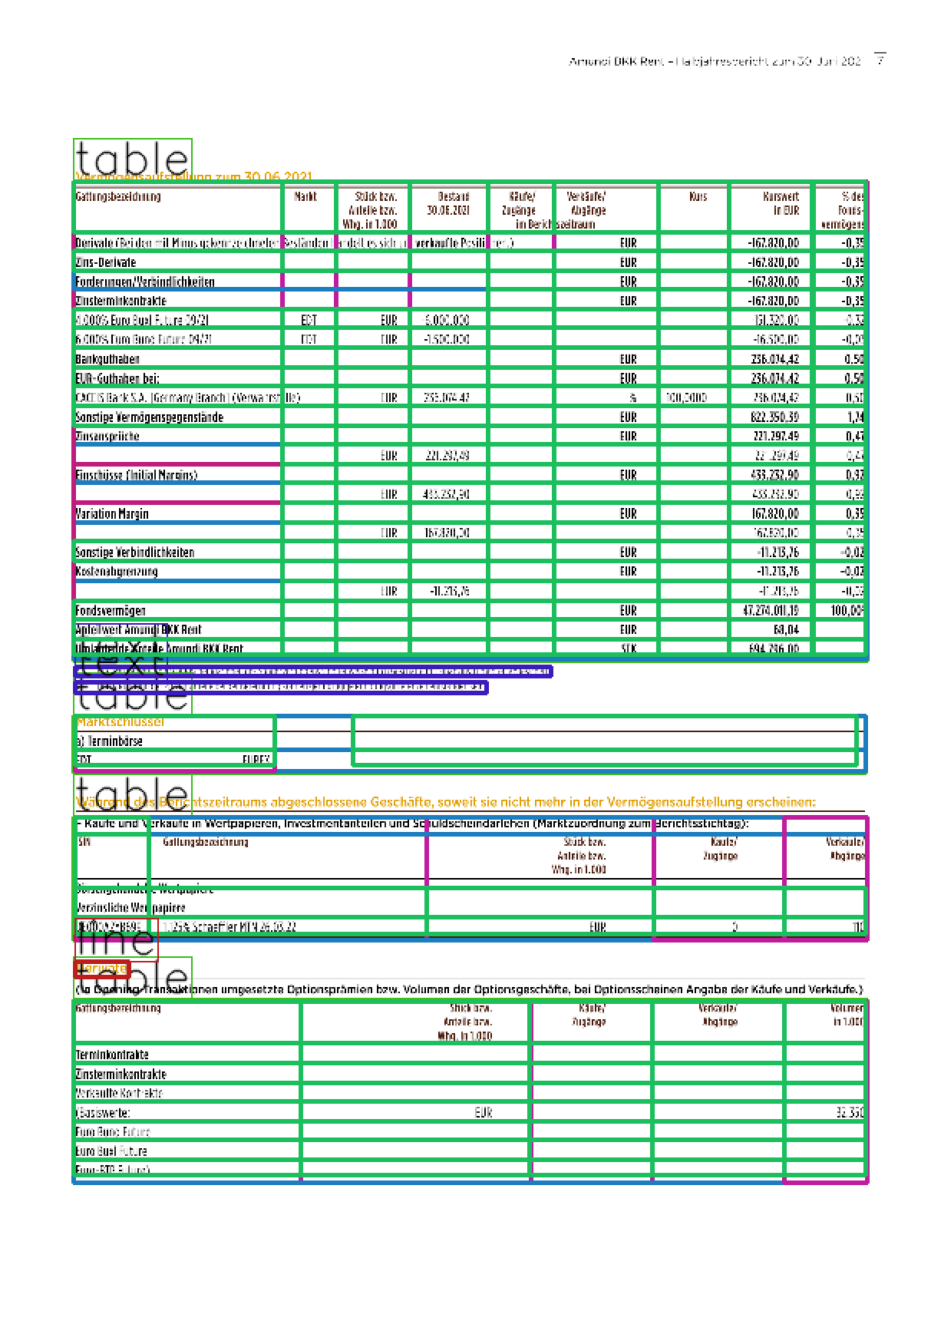

[0815 19:37.26 @context.py:156]  INF  ImageLayoutService total: 1.9919 sec.
[0815 19:37.28 @context.py:156]  INF  ImageLayoutService total: 1.9491 sec.
[0815 19:37.30 @context.py:156]  INF  ImageLayoutService total: 1.8747 sec.


annotations before/after undo: 698 20
round-trip: 20 of 698 annotations restored

1 chunks -> /content/out/chunks.jsonl
{
  "document_id": "e3fccf5c-d18f-3e28-867c-afddc2749762",
  "page": 3,
  "order": -1,
  "category": "table_html",
  "annotation_id": "f7d5a342-f6b3-3a43-a3c7-1dd91e9c0fce",
  "text": "<table><tr><td colspan=5></td></tr><tr><td></td><td></td><td></td><td></td><td></td></tr><tr><td></td><td></td><td></td><td></td><td></td></tr><tr><td></td><td></td><td></td><td></td><td></td></tr><tr><td></td><td><


In [2]:
for i, p in enumerate(pages):
    p.save(image_to_json=False, path=OUT / f"page_{i}.json")

restored = dd.Page.from_file(str(OUT / "page_0.json"))
print("round-trip:", len(restored.get_annotation()), "of",
      len(pages[0].get_annotation()), "annotations restored")

records = []
for p in pages:
    for doc_id, img_id, pno, ann_id, order, cat, txt in p.chunks:
        if txt and txt.strip():
            records.append({"document_id": doc_id, "page": pno, "order": order,
                            "category": str(cat), "annotation_id": ann_id, "text": txt})
    for t in p.tables:
        records.append({"document_id": p.document_id, "page": p.page_number,
                        "order": -1, "category": "table_html",
                        "annotation_id": t.annotation_id, "text": t.html})

(OUT / "chunks.jsonl").write_text("\n".join(json.dumps(r) for r in records))
print(f"\n{len(records)} chunks -> {OUT/'chunks.jsonl'}")
print(json.dumps(records[0], indent=2)[:400])